In [ ]:
import pandas as pd

df = pd.read_csv("..\data\processed\clean_prs.csv")
df.head()

,pr_id,repo_name,pr_number,title,body_len,user_login,user_type,created_datetime,closed_datetime,merged_datetime,...,commits,additions,deletions,changed_files,repo_language,repo_stars,repo_forks,is_fpt,keyword,is_merged
0,1217900573,nduybao/Train,1,prj301,0,ThanhPhong31,User,2023-01-26 13:49:23,2023-01-26 13:49:38,2023-01-26 13:49:38,...,1,3900,0,41,Java,0,0,1,PRJ301,1
1,1285249723,Henrily041103/PRJ301_SP2023,18,https://github.com/Henrily041103/PRJ301_SP2023...,0,wave-npa,User,2023-03-22 05:26:17,2023-03-22 06:02:53,2023-03-22 06:02:53,...,2,45,38,8,Java,0,3,1,PRJ301,1
2,1476177616,NoFearTeam2023/FPT-Capstone-UpReach-Project,36,Ha/fe,0,hoanganh1810tx,User,2023-08-15 16:34:46,2023-08-15 16:35:16,2023-08-15 16:35:16,...,2,38,14,5,JavaScript,0,0,1,Capstone FPT,1
3,1478047761,NoFearTeam2023/FPT-Capstone-UpReach-Project,39,Be hieu update,0,quanqhieu07,User,2023-08-16 20:39:13,2023-08-17 13:16:34,NaN,...,3,466,301,5,JavaScript,0,0,1,Capstone FPT,0
4,1479032519,NoFearTeam2023/FPT-Capstone-UpReach-Project,41,Be hieu update,0,quanqhieu07,User,2023-08-17 13:17:04,2023-08-17 14:43:44,2023-08-17 14:43:44,...,4,464,301,5,JavaScript,0,0,1,Capstone FPT,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pr_id                1771 non-null   int64  
 1   repo_name            1771 non-null   object 
 2   pr_number            1771 non-null   int64  
 3   title                1771 non-null   object 
 4   body_len             1771 non-null   int64  
 5   user_login           1771 non-null   object 
 6   user_type            1771 non-null   object 
 7   created_datetime     1771 non-null   object 
 8   closed_datetime      1771 non-null   object 
 9   merged_datetime      1647 non-null   object 
 10  created_hour         1771 non-null   int64  
 11  created_day_of_week  1771 non-null   int64  
 12  duration_minutes     1771 non-null   float64
 13  duration_hours       1771 non-null   float64
 14  comments             1771 non-null   int64  
 15  review_comments      1771 non-null   i

## Data Preprocessing

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Drop irrelevant columns
df_processed = df.drop(columns=[
    'pr_id', 'repo_name', 'pr_number', 'title', 'body_len', 'user_login', 'merged_datetime',
    'created_datetime', 'closed_datetime' # Dropping datetime objects after considering duration_minutes and duration_hours as sufficient tie-based features.
])

# Identify categorical columns for one-hot encoding
categorical_cols = ['user_type', 'repo_language', 'keyword']

# Apply one-hot encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

# Display the first few rows of the processed DataFrame and its info to verify
display(df_processed.head())
df_processed.info()

,created_hour,created_day_of_week,duration_minutes,duration_hours,comments,review_comments,commits,additions,deletions,changed_files,...,repo_language_PHP,repo_language_Python,repo_language_Ruby,repo_language_TSQL,repo_language_TypeScript,repo_language_Unknown,keyword_PRJ301,keyword_SEP490,keyword_SWP391,keyword_global
0,13,4,0.250000,0.004167,0,0,1,3900,0,41,...,False,False,False,False,False,False,True,False,False,False
1,5,3,36.600000,0.610000,0,0,2,45,38,8,...,False,False,False,False,False,False,True,False,False,False
2,16,2,0.500000,0.008333,1,0,2,38,14,5,...,False,False,False,False,False,False,False,False,False,False
3,20,3,997.350000,16.622500,1,0,3,466,301,5,...,False,False,False,False,False,False,False,False,False,False
4,13,4,86.666667,1.444444,1,0,4,464,301,5,...,False,False,False,False,False,False,False,False,False,False


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1771 entries, 0 to 1770
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   created_hour              1771 non-null   int64  
 1   created_day_of_week       1771 non-null   int64  
 2   duration_minutes          1771 non-null   float64
 3   duration_hours            1771 non-null   float64
 4   comments                  1771 non-null   int64  
 5   review_comments           1771 non-null   int64  
 6   commits                   1771 non-null   int64  
 7   additions                 1771 non-null   int64  
 8   deletions                 1771 non-null   int64  
 9   changed_files             1771 non-null   int64  
 10  repo_stars                1771 non-null   int64  
 11  repo_forks                1771 non-null   int64  
 12  is_fpt                    1771 non-null   int64  
 13  is_merged                 1771 non-null   int64  
 14  repo_lan

## Model Training: Random Forest Classifier

In [7]:
# Define features (X) and target (y)
X = df_processed.drop('is_merged', axis=1)
y = df_processed['is_merged']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced') # Using class_weight to handle potential imbalance
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Training set size: 1416 samples
Testing set size: 355 samples
Random Forest model trained successfully!


## Model Evaluation and Visualization

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.52      0.68        25
           1       0.96      1.00      0.98       330

    accuracy                           0.97       355
   macro avg       0.98      0.76      0.83       355
weighted avg       0.97      0.97      0.96       355



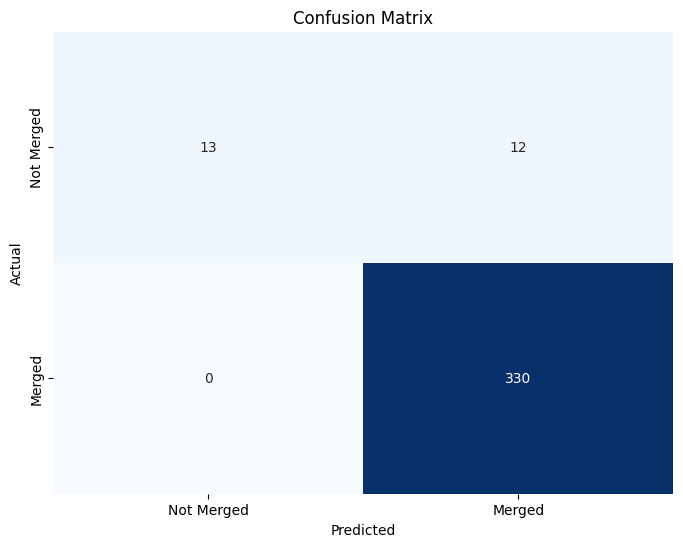

In [8]:
# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Print classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Merged', 'Merged'],
            yticklabels=['Not Merged', 'Merged'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

### Confusion Matrix Analysis

The confusion matrix provides a detailed breakdown of correct and incorrect classifications:

- **True Positives (TP)**: Correctly predicted merged pull requests. (Actual: Merged, Predicted: Merged)
- **True Negatives (TN)**: Correctly predicted not-merged pull requests. (Actual: Not Merged, Predicted: Not Merged)
- **False Positives (FP)**: Incorrectly predicted merged pull requests. (Actual: Not Merged, Predicted: Merged) - Type I error.
- **False Negatives (FN)**: Incorrectly predicted not-merged pull requests. (Actual: Merged, Predicted: Not Merged) - Type II error.

From the confusion matrix generated above:
- **True Negatives (TN)**: **13** (The model correctly identified 13 pull requests as 'Not Merged' that were actually 'Not Merged').
- **False Positives (FP)**: **12** (The model incorrectly identified 12 pull requests as 'Merged' that were actually 'Not Merged').
- **False Negatives (FN)**: **0** (The model incorrectly identified 0 pull requests as 'Not Merged' that were actually 'Merged'). This is excellent, indicating no missed merged PRs.
- **True Positives (TP)**: **330** (The model correctly identified 330 pull requests as 'Merged' that were actually 'Merged').

**Interpretation:**

The model demonstrates very high recall for the 'Merged' class (100%), meaning it successfully identified all actual merged pull requests. However, it has a lower precision for the 'Not Merged' class, with 12 false positives. This suggests the model is very good at identifying merged PRs but sometimes misclassifies non-merged PRs as merged. Given the likely class imbalance (more merged than non-merged PRs), the `class_weight='balanced'` parameter in the RandomForestClassifier helped improve the model's ability to identify the minority class ('Not Merged').

## Feature Importances

Let's visualize the feature importances from the trained Random Forest model to understand which features were most influential in predicting whether a pull request is merged.

/tmp/ipykernel_1584/108644698.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


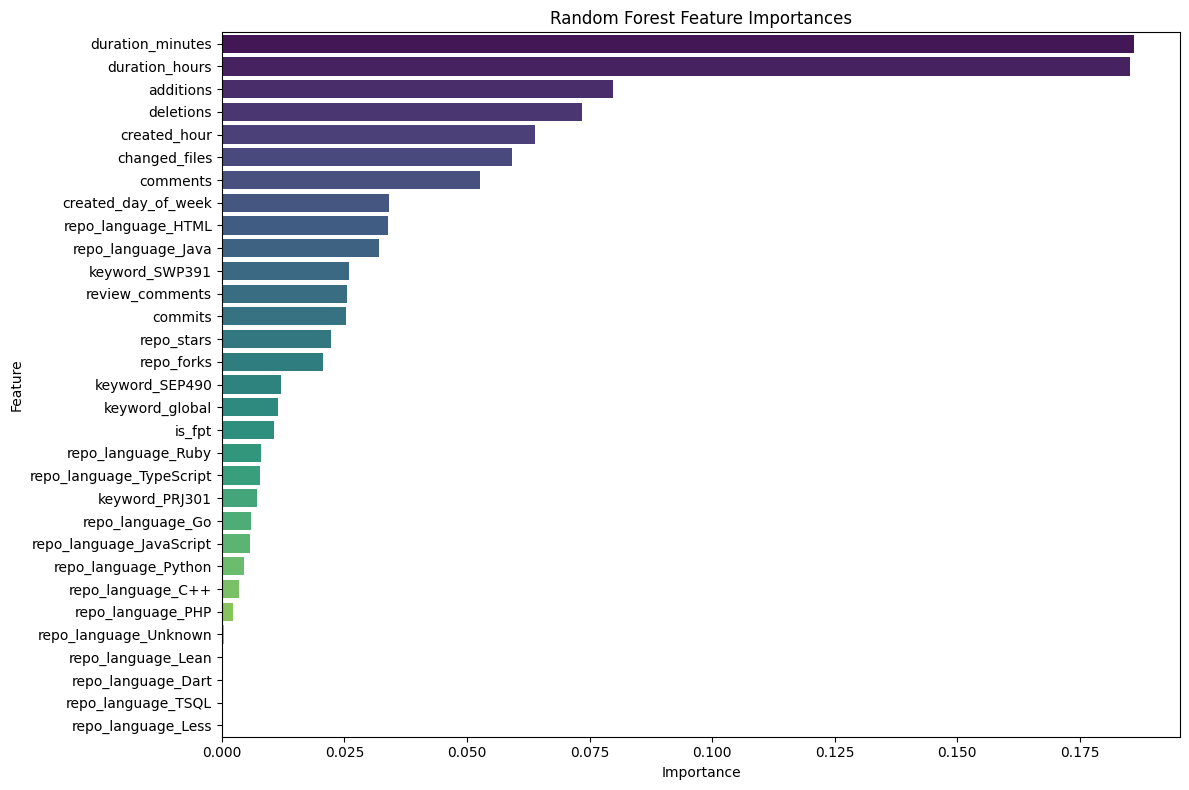

In [9]:
# Get feature importances from the trained Random Forest model
feature_importances = rf_model.feature_importances_

# Get feature names from the training data
feature_names = X_train.columns

# Create a DataFrame for better visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})

# Sort features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()